# Multi-modal AI System for Quality Inspection and VQA
This notebook implements a complete multi-task learning architecture combining a Vision Pipeline and a VQA Pipeline for industrial defect detection, specifically using the MVTec AD `metal_nut` dataset.

## Step 1: Environment Setup & Imports
Installing required libraries and setting up device configuration.

In [12]:
#!pip install -q torch torchvision transformers opencv-python matplotlib albumentations numpy requests tqdm

In [13]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import tarfile
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.models import resnet18, ResNet18_Weights

from transformers import DistilBertModel, DistilBertTokenizer

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cpu':
    print('⚠️ WARNING: CPU environment detected. Training will be extremely slow!')
    print('💡 TIP: Please switch to a GPU environment (e.g., Google Colab T4 GPU) for practical training times.')
if torch.cuda.is_available():
    print(f'GPU Memory Total: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')

c:\Users\asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
GPU Memory Total: 4.29 GB


## Step 2: Exploratory Data Analysis (EDA) & Preprocessing
Downloading the dataset and preparing PyTorch Datasets.

In [14]:
# Dataset directory
DATA_DIR = './dataset'
print(f"Using dataset from {DATA_DIR}/metal_nut")

Using dataset from ./dataset/metal_nut


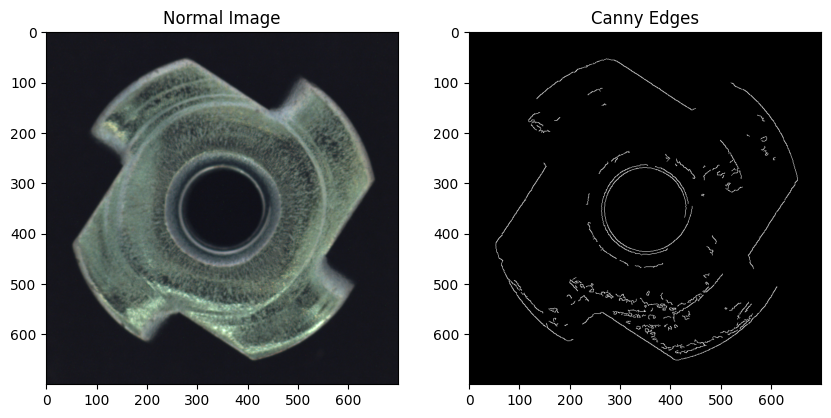

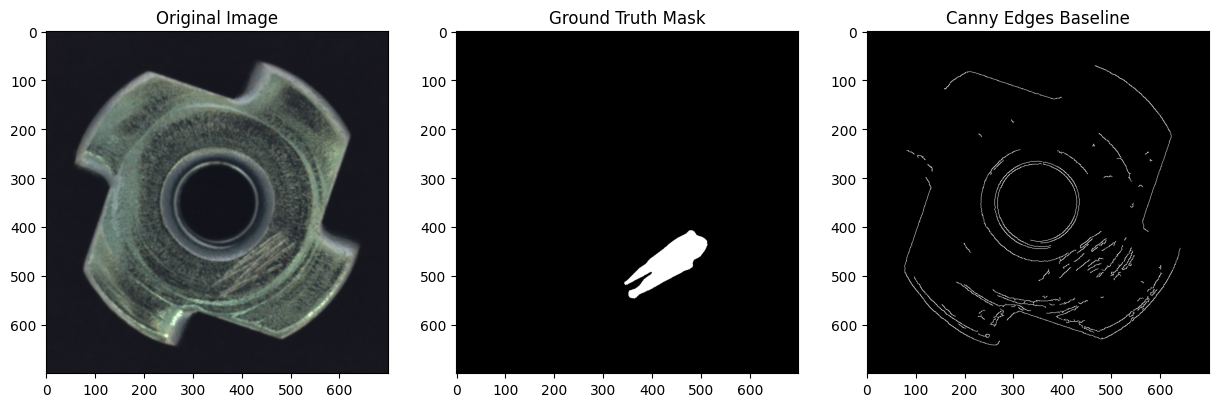

In [15]:
# EDA: Visualizing Normal vs Defect
def show_sample(img_path, mask_path=None):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Simple Digital Image Processing Baseline (Canny Edge)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gray, 100, 200)
    
    if mask_path:
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        axes[0].imshow(img)
        axes[0].set_title('Original Image')
        axes[1].imshow(mask, cmap='gray')
        axes[1].set_title('Ground Truth Mask')
        axes[2].imshow(edges, cmap='gray')
        axes[2].set_title('Canny Edges Baseline')
        plt.show()
    else:
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        axes[0].imshow(img)
        axes[0].set_title('Normal Image')
        axes[1].imshow(edges, cmap='gray')
        axes[1].set_title('Canny Edges')
        plt.show()

# Show a normal sample
normal_dir = os.path.join(DATA_DIR, 'metal_nut/train/good')
normal_files = os.listdir(normal_dir)
if normal_files:
    show_sample(os.path.join(normal_dir, normal_files[0]))

# Show an anomalous sample
scratch_dir = os.path.join(DATA_DIR, 'metal_nut/test/scratch')
mask_dir = os.path.join(DATA_DIR, 'metal_nut/ground_truth/scratch')
if os.path.exists(scratch_dir):
    scratch_files = os.listdir(scratch_dir)
    if scratch_files:
        img_name = scratch_files[0]
        mask_name = img_name.replace('.png', '_mask.png')
        show_sample(os.path.join(scratch_dir, img_name), os.path.join(mask_dir, mask_name))

In [16]:
# Dataset definition
import random
class DefectDataset(Dataset):
    def __init__(self, root_dir, split='train', img_size=224):
        self.root_dir = root_dir
        self.split = split
        self.img_size = img_size
        
        # Define some basic VQA questions
        self.vocab = {"yes": 0, "no": 1, "scratch": 2, "bent": 3, "color": 4, "flip": 5, "good": 6}
        self.idx2vocab = {v: k for k, v in self.vocab.items()}
        
        master_list = []
        base_dir = os.path.join(root_dir, 'metal_nut')
        
        # Traverse BOTH original train and test folders
        for orig_split in ['train', 'test']:
            split_dir = os.path.join(base_dir, orig_split)
            if not os.path.exists(split_dir): continue
            categories = os.listdir(split_dir)
            for cat in categories:
                cat_dir = os.path.join(split_dir, cat)
                if not os.path.isdir(cat_dir): continue
                for img_name in os.listdir(cat_dir):
                    if not img_name.endswith('.png'): continue
                    img_path = os.path.join(cat_dir, img_name)
                    
                    has_defect = (cat != 'good')
                    mask_path = None
                    if has_defect:
                        mask_name = img_name.replace('.png', '_mask.png')
                        mask_path = os.path.join(base_dir, 'ground_truth', cat, mask_name)
                    
                    # Create synthetic Q&A
                    questions = []
                    if has_defect:
                        questions.append(("Is there a defect?", "yes"))
                        questions.append(("What type of defect is this?", cat))
                    else:
                        questions.append(("Is there a defect?", "no"))
                        questions.append(("What type of defect is this?", "good"))
                    
                    for q, a in questions:
                        if a in self.vocab:
                            master_list.append({
                                'image_path': img_path,
                                'mask_path': mask_path,
                                'question': q,
                                'answer_label': self.vocab[a],
                                'category': cat
                            })
        
        # Shuffle master list with a fixed seed
        random.seed(42)
        random.shuffle(master_list)
        
        # Custom 80/20 Split
        split_idx = int(0.8 * len(master_list))
        if self.split == 'train':
            self.samples = master_list[:split_idx]
        else:
            self.samples = master_list[split_idx:]
                        
        if self.split == 'train':
            self.transform = T.Compose([
                T.Resize((self.img_size, self.img_size)),
                T.RandomHorizontalFlip(p=0.5),
                T.RandomVerticalFlip(p=0.5),
                T.ColorJitter(brightness=0.2, contrast=0.2),
                T.ToTensor(),
                T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ])
        else:
            self.transform = T.Compose([
                T.Resize((self.img_size, self.img_size)),
                T.ToTensor(),
                T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        img = Image.open(sample['image_path']).convert('RGB')
        orig_w, orig_h = img.size
        
        img_tensor = self.transform(img)
        
        # Load or generate mask
        mask_tensor = torch.zeros((1, self.img_size, self.img_size))
        bbox = torch.zeros(4) # [x_center, y_center, width, height]
        has_defect = 0.0
        
        if sample['mask_path'] and os.path.exists(sample['mask_path']):
            mask = Image.open(sample['mask_path']).convert('L')
            mask = mask.resize((self.img_size, self.img_size), Image.NEAREST)
            mask_np = np.array(mask) / 255.0
            mask_tensor = torch.tensor(mask_np, dtype=torch.float32).unsqueeze(0)
            
            # Generate bbox from mask
            y_indices, x_indices = np.where(mask_np > 0.5)
            if len(y_indices) > 0:
                y1, y2 = y_indices.min(), y_indices.max()
                x1, x2 = x_indices.min(), x_indices.max()
                xc = (x1 + x2) / 2.0 / self.img_size
                yc = (y1 + y2) / 2.0 / self.img_size
                w = (x2 - x1) / self.img_size
                h = (y2 - y1) / self.img_size
                bbox = torch.tensor([xc, yc, w, h], dtype=torch.float32)
                has_defect = 1.0
                
        return {
            'image': img_tensor,
            'mask': mask_tensor,
            'bbox': bbox,
            'has_defect': torch.tensor([has_defect], dtype=torch.float32),
            'question': sample['question'],
            'answer': torch.tensor(sample['answer_label'], dtype=torch.long)
        }

# Batch size: 8 is very safe for 4GB-8GB VRAM, can be increased if you have Colab T4 15GB
BATCH_SIZE = 8
train_dataset = DefectDataset(DATA_DIR, split='train')
test_dataset = DefectDataset(DATA_DIR, split='test')

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")


Train samples: 536
Test samples: 134


## Step 3: Vision Backbone & Heads
Defining ResNet18 backbone, U-Net Segmentation Head, and Simplified Anchor-Free Detection Head.

In [17]:
class VisionPipeline(nn.Module):
    def __init__(self, img_size=256):
        super().__init__()
        self.img_size = img_size
        
        # Backbone (ResNet18)
        resnet = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        self.backbone = nn.Sequential(*list(resnet.children())[:-2]) # output shape: [B, 512, H/32, W/32]
        
        # Segmentation Head (U-Net style lightweight decoder)
        self.seg_decoder = nn.Sequential(
            nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2), # H/16
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2),   # H
            nn.ReLU(),
            nn.Conv2d(16, 1, kernel_size=1) # Output mask [B, 1, H, W]
        )
        
        # Detection Head (Simplified anchor-free: CenterNet style)
        # Predicts 1 object per image for simplicity (Defect bounding box)
        self.det_head = nn.Sequential(
            nn.Conv2d(512, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1), # [B, 256, 1, 1]
            nn.Flatten(),
            nn.Linear(256, 5) # [prob_defect, xc, yc, w, h]
        )
        
    def forward(self, x):
        features = self.backbone(x)
        
        # Segmentation Branch
        mask_logits = self.seg_decoder(features)
        
        # Detection Branch
        det_output = self.det_head(features)
        defect_logits = det_output[:, 0:1] # [B, 1]
        bbox_preds = torch.sigmoid(det_output[:, 1:5]) # [B, 4] (normalized 0-1)
        
        return features, mask_logits, defect_logits, bbox_preds

## Step 4: Language Model & Fusion
Using DistilBERT for text encoding and a Cross-Attention mechanism to fuse visual and textual embeddings.

In [18]:
class MultiModalModel(nn.Module):
    def __init__(self, vocab_size, vision_pipeline):
        super().__init__()
        self.vision = vision_pipeline
        
        # Text Encoder
        self.tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
        self.text_encoder = DistilBertModel.from_pretrained('distilbert-base-uncased')
        for param in self.text_encoder.parameters():
            param.requires_grad = False # Freeze BERT to save VRAM
            
        # Fusion Module (Cross-Attention)
        self.visual_proj = nn.Linear(512, 768) # ResNet output (512) to BERT hidden size (768)
        self.cross_attention = nn.MultiheadAttention(embed_dim=768, num_heads=8, batch_first=True)
        
        # VQA Head
        self.vqa_classifier = nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, vocab_size)
        )
        
    def forward(self, images, questions):
        B = images.size(0)
        
        # 1. Vision Forward
        visual_features, mask_logits, defect_logits, bbox_preds = self.vision(images)
        
        # 2. Process Visual Features for Fusion
        # visual_features: [B, 512, H/32, W/32]
        H, W = visual_features.size(2), visual_features.size(3)
        visual_flat = visual_features.view(B, 512, -1).permute(0, 2, 1) # [B, H*W, 512]
        visual_emb = self.visual_proj(visual_flat) # [B, H*W, 768]
        
        # 3. Text Forward
        encoded_text = self.tokenizer(questions, padding=True, truncation=True, return_tensors='pt', max_length=32).to(images.device)
        text_emb = self.text_encoder(**encoded_text).last_hidden_state # [B, seq_len, 768]
        
        # 4. Fusion (Text attends to Visual)
        fused_emb, _ = self.cross_attention(query=text_emb, key=visual_emb, value=visual_emb)
        
        # Pool the fused embeddings (use the CLS token representation)
        pooled_fused_emb = fused_emb[:, 0, :] # [B, 768]
        
        # 5. VQA Output
        vqa_logits = self.vqa_classifier(pooled_fused_emb)
        
        return mask_logits, defect_logits, bbox_preds, vqa_logits

## Step 5: Multi-task Loss & Optimizer
Defining a composite loss function for Segmentation, Detection, and VQA.

In [19]:
# Loss weights
lambda_seg = 1.0
lambda_det_cls = 1.0
lambda_det_box = 5.0
lambda_vqa = 1.0

seg_criterion = nn.BCEWithLogitsLoss()
det_cls_criterion = nn.BCEWithLogitsLoss()
det_box_criterion = nn.MSELoss(reduction='none')
vqa_criterion = nn.CrossEntropyLoss()

def dice_loss(pred, target, smooth=1.):
    pred = torch.sigmoid(pred)
    pred = pred.contiguous()
    target = target.contiguous()
    intersection = (pred * target).sum(dim=2).sum(dim=2)
    loss = (1 - ((2. * intersection + smooth) / (pred.sum(dim=2).sum(dim=2) + target.sum(dim=2).sum(dim=2) + smooth)))
    return loss.mean()

def compute_loss(mask_logits, defect_logits, bbox_preds, vqa_logits, batch):
    # 1. Segmentation Loss
    loss_seg_bce = seg_criterion(mask_logits, batch['mask'].to(device))
    loss_seg_dice = dice_loss(mask_logits, batch['mask'].to(device))
    loss_seg = loss_seg_bce + loss_seg_dice

    # 2. Detection Loss
    gt_has_defect = batch['has_defect'].to(device)
    gt_bbox = batch['bbox'].to(device)

    loss_det_cls = det_cls_criterion(defect_logits, gt_has_defect)

    # Box loss only computed if there is a defect in ground truth
    loss_box = det_box_criterion(bbox_preds, gt_bbox).sum(dim=1)
    loss_det_box = (loss_box * gt_has_defect.view(-1)).mean() # Average over batch

    # 3. VQA Loss
    loss_vqa = vqa_criterion(vqa_logits, batch['answer'].to(device))

    total_loss = (lambda_seg * loss_seg) + (lambda_det_cls * loss_det_cls) + (lambda_det_box * loss_det_box) + (lambda_vqa * loss_vqa)

    return total_loss, loss_seg, loss_det_cls, loss_det_box, loss_vqa


## Step 6: Training Loop
Modular training and validation loop tracking all metrics.

In [9]:
# Initialize Model
vision_net = VisionPipeline().to(device)
model = MultiModalModel(vocab_size=len(train_dataset.vocab), vision_pipeline=vision_net).to(device)

optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4, weight_decay=1e-4)
EPOCHS = 25
best_loss = float('inf')

print("Starting Training...")
for epoch in range(EPOCHS):
    model.train()
    total_train_loss = 0.0

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    for batch in progress_bar:
        images = batch['image'].to(device)
        questions = batch['question']

        optimizer.zero_grad()

        mask_logits, defect_logits, bbox_preds, vqa_logits = model(images, questions)

        loss, l_seg, l_dcls, l_dbox, l_vqa = compute_loss(mask_logits, defect_logits, bbox_preds, vqa_logits, batch)

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        progress_bar.set_postfix({'loss': f"{loss.item():.4f}", 'vqa_l': f"{l_vqa.item():.4f}"})

    avg_loss = total_train_loss / len(train_loader)
    print(f"Epoch {epoch+1} - Average Training Loss: {avg_loss:.4f}")
    
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model.state_dict(), 'best_model.pth')
        print(f'  >> Saved new best model with loss: {best_loss:.4f}')


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Starting Training...


Epoch 1/25: 100%|███████████████████████████████████████████| 67/67 [00:56<00:00,  1.20it/s, loss=2.3597, vqa_l=1.1397]


Epoch 1 - Average Training Loss: 3.2974
  >> Saved new best model with loss: 3.2974


...

Epoch 23 - Average Training Loss: 0.1862


Epoch 24/25: 100%|██████████████████████████████████████████| 67/67 [01:10<00:00,  1.05s/it, loss=0.0021, vqa_l=0.0000]


Epoch 24 - Average Training Loss: 0.1565
  >> Saved new best model with loss: 0.1565


Epoch 25/25: 100%|██████████████████████████████████████████| 67/67 [01:08<00:00,  1.02s/it, loss=0.0386, vqa_l=0.0000]

Epoch 25 - Average Training Loss: 0.1658


## Step 7: Evaluation & Visualization
Running inference on the test set and visualizing the multi-modal outputs.

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\asus/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 35.3MB/s]
Loading weights: 100%|██████████| 100/100 [00:00<00:00, 9491.95it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Đã nạp thành công mô hình MultiModalModel v2!
Loaded best model weights for evaluation.


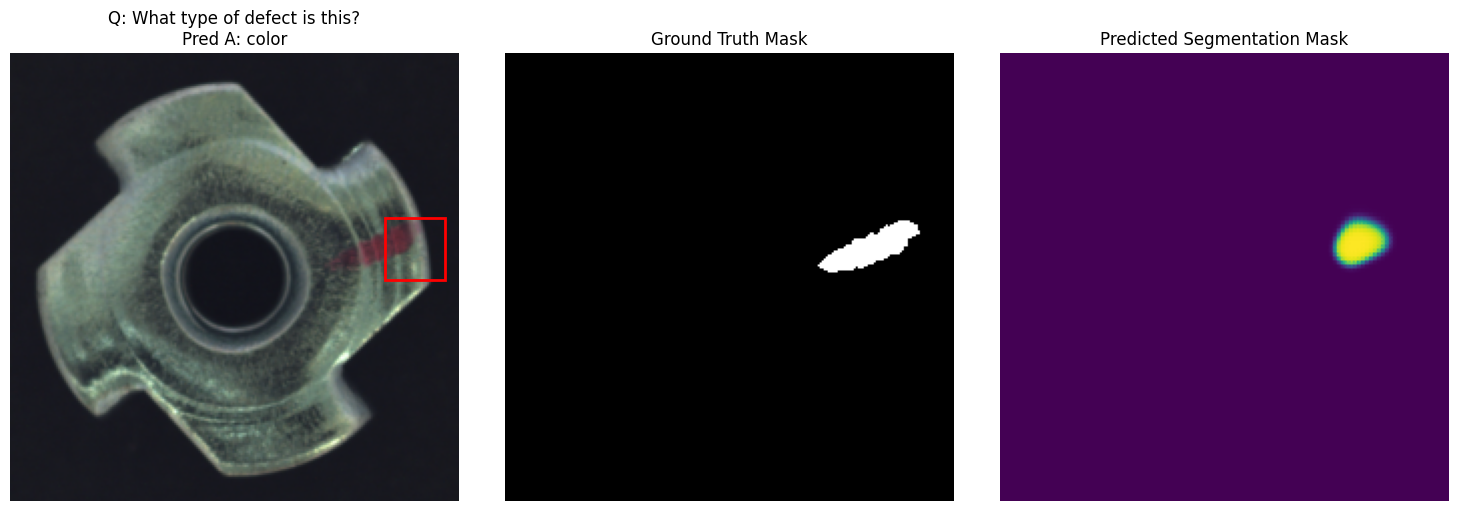

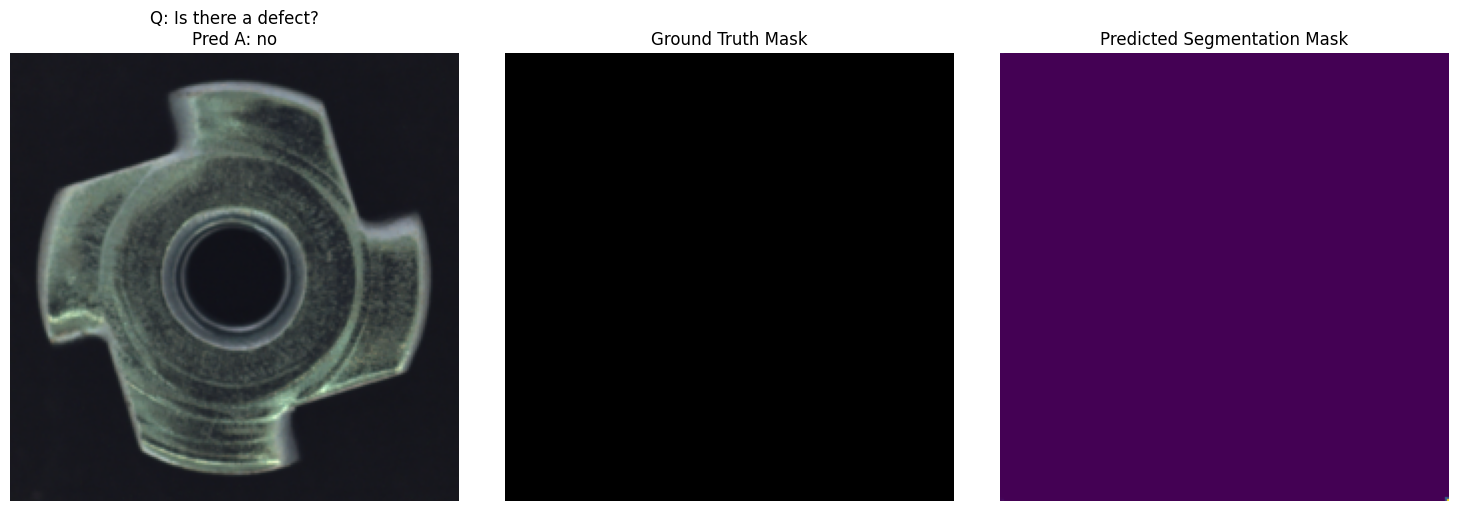

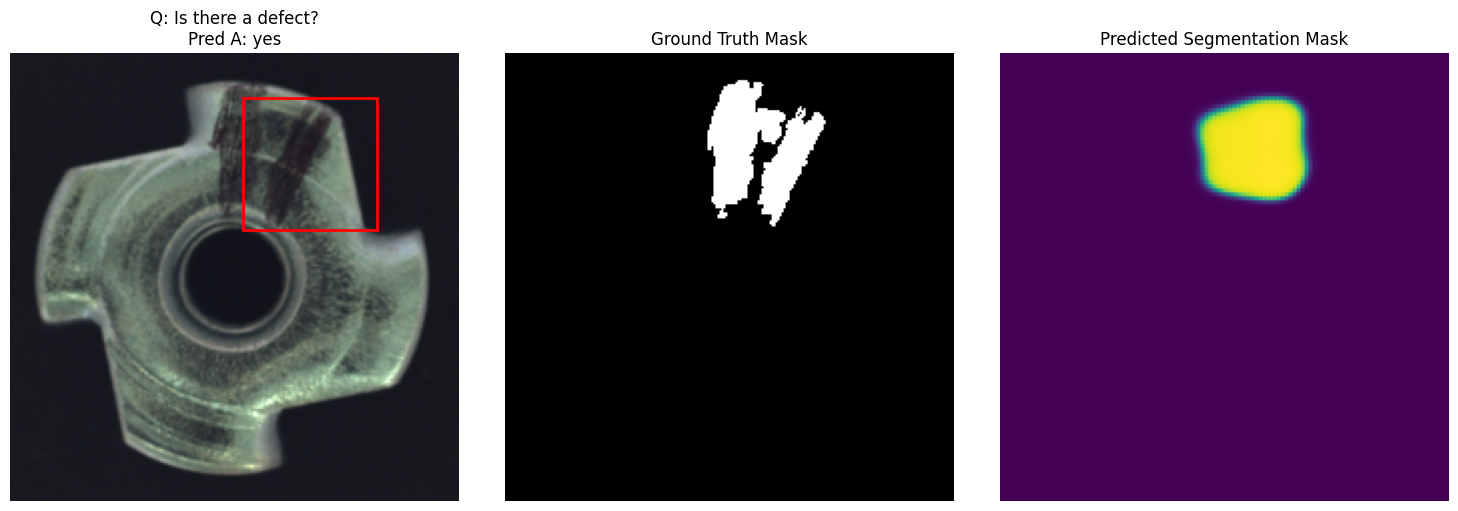

In [21]:
import os
# Khởi tạo mô hình
vision_net = VisionPipeline().to(device)
model = MultiModalModel(vocab_size=len(train_dataset.vocab), vision_pipeline=vision_net).to(device)

# Load pth thay vì phải train
model.load_state_dict(torch.load('best_model.pth', map_location=device))
model.eval()

print("Đã nạp thành công mô hình MultiModalModel v2!")

if os.path.exists('best_model.pth'):
    model.load_state_dict(torch.load('best_model.pth', map_location=device))
    print('Loaded best model weights for evaluation.')
model.eval()

# Helper function to convert normalized bbox to image pixels
def unnormalize_bbox(bbox, img_size):
    xc, yc, w, h = bbox
    x1 = int((xc - w/2) * img_size)
    y1 = int((yc - h/2) * img_size)
    x2 = int((xc + w/2) * img_size)
    y2 = int((yc + h/2) * img_size)
    return x1, y1, x2, y2

# Take a batch from test set
batch = next(iter(test_loader))
images = batch['image'].to(device)
questions = batch['question']

with torch.no_grad():
    mask_logits, defect_logits, bbox_preds, vqa_logits = model(images, questions)
    
    pred_masks = torch.sigmoid(mask_logits).cpu().numpy()
    pred_defect_probs = torch.sigmoid(defect_logits).cpu().numpy()
    pred_bboxes = bbox_preds.cpu().numpy()
    pred_answers = torch.argmax(vqa_logits, dim=1).cpu().numpy()

# Denormalize image for display
def denormalize_img(tensor):
    mean = np.array([0.485, 0.456, 0.406]).reshape((3, 1, 1))
    std = np.array([0.229, 0.224, 0.225]).reshape((3, 1, 1))
    img = tensor.cpu().numpy()
    img = std * img + mean
    img = np.clip(img, 0, 1)
    return np.transpose(img, (1, 2, 0))

# Visualize first 3 samples in the batch
for i in range(min(3, BATCH_SIZE)):
    img_disp = denormalize_img(batch['image'][i])
    gt_mask = batch['mask'][i].squeeze().numpy()
    
    # Predicted components
    pred_mask = pred_masks[i].squeeze()
    pred_answer_text = train_dataset.idx2vocab[pred_answers[i]]
    prob_defect = pred_defect_probs[i][0]
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # 1. Original Image with Bounding Box
    ax = axes[0]
    ax.imshow(img_disp)
    if prob_defect > 0.5:
        x1, y1, x2, y2 = unnormalize_bbox(pred_bboxes[i], 256)
        rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor='red', linewidth=2)
        ax.add_patch(rect)
    ax.set_title(f"Q: {questions[i]}\nPred A: {pred_answer_text}")
    ax.axis('off')
    
    # 2. Ground Truth Mask
    axes[1].imshow(gt_mask, cmap='gray')
    axes[1].set_title('Ground Truth Mask')
    axes[1].axis('off')
    
    # 3. Predicted Mask
    axes[2].imshow(pred_mask, cmap='viridis')
    axes[2].set_title('Predicted Segmentation Mask')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()